# Morton Coverage Example

`mortie.morton_coverage()` computes the set of morton indices at a given HEALPix order
that completely cover a polygon defined by lat/lon vertices.

**Key properties:**
- **Complete** — every cell whose centre lies inside the polygon is included
- **Compact** — only boundary cells and interior cells are returned (no excess)
- **Correct** — uses gnomonic projection + winding-number point-in-polygon, which works in any hemisphere

**Parameters:**
- `lats`, `lons` — vertex coordinates (degrees). For multipart polygons, pass lists of arrays.
- `order` — HEALPix depth (1--18). Higher order = finer cells = more cells.

This notebook visualises coverage at different orders for synthetic and real-world polygons.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import healpy as hp
from shapely.geometry import Polygon as ShapelyPolygon
import mortie
import time
from pathlib import Path

### Visualisation helpers

The cell below defines three helper functions:
- `morton_cell_geometries()` — converts morton indices to Shapely polygons for plotting (handles pole-touching cells via stereographic projection)
- `plot_polygon_boundary()` — draws polygon edges, splitting at antimeridian crossings
- `plot_coverage()` — combines both: runs `morton_coverage`, renders cells and boundary on a cartopy axis

In [2]:
def morton_cell_geometries(morton_indices, step=16):
    """Get shapely Polygon geometries for each morton cell in lon/lat coords."""
    nested, order = mortie.mort2healpix(morton_indices)
    nested = np.atleast_1d(nested)
    nside = 2**order

    geoms = []
    for pix in nested:
        xyz = hp.boundaries(nside, pix, step=step, nest=True)
        lons, lats = hp.vec2ang(xyz.T, lonlat=True)

        # Cell center longitude for normalization (handles 0/360 and antimeridian)
        center_lon, _ = hp.pix2ang(nside, pix, nest=True, lonlat=True)
        if center_lon > 180:
            center_lon -= 360

        # Detect pole-touching cells: any vertex with |lat| > 89.5°
        if np.any(np.abs(lats) > 89.5):
            # Use polar stereographic projection to avoid longitude wrapping
            pole_lat = -90.0 if np.mean(lats) < 0 else 90.0
            sign = -1.0 if pole_lat < 0 else 1.0
            lats_r = np.radians(lats)
            lons_r = np.radians(lons)
            # Stereographic projection centered on the pole
            k = 2.0 / (1.0 + sign * np.sin(lats_r))
            sx = k * np.cos(lats_r) * np.cos(lons_r)
            sy = k * np.cos(lats_r) * np.sin(lons_r)
            # Build polygon in projected space and densify
            poly_proj = ShapelyPolygon(zip(sx, sy))
            # Densify: interpolate along the projected boundary
            boundary = poly_proj.exterior
            n_pts = max(64, len(lons))
            distances = np.linspace(0, boundary.length, n_pts, endpoint=False)
            pts = [boundary.interpolate(d) for d in distances]
            sx_d = np.array([p.x for p in pts])
            sy_d = np.array([p.y for p in pts])
            # Inverse stereographic: back to lon/lat
            rho = np.sqrt(sx_d**2 + sy_d**2)
            c = 2.0 * np.arctan2(rho, 2.0)
            out_lats = np.degrees(np.arcsin(sign * np.cos(c)))
            out_lons = np.degrees(np.arctan2(sy_d, sx_d))
            # At the exact pole, atan2(0,0)=0 is wrong; use cell center instead
            out_lons[rho < 1e-10] = center_lon
            # Normalize longitudes relative to cell center for continuity
            out_lons = center_lon + ((out_lons - center_lon + 180) % 360 - 180)
            geoms.append(ShapelyPolygon(zip(out_lons, out_lats)))
        else:
            # Normalize longitudes relative to cell center (handles 0/360 seam
            # and antimeridian crossings without sequential unwrapping)
            lons = center_lon + ((lons - center_lon + 180) % 360 - 180)
            geoms.append(ShapelyPolygon(zip(lons, lats)))
    return geoms

def plot_polygon_boundary(lons, lats, ax, **kwargs):
    """Plot a polygon boundary handling antimeridian crossings.
    
    Splits the line at longitude jumps > 180° so cartopy doesn't
    draw straight lines across the map.
    """
    poly_lons = np.append(lons, lons[0])
    poly_lats = np.append(lats, lats[0])
    
    # Split at antimeridian crossings
    segments_lon = []
    segments_lat = []
    seg_lon = [poly_lons[0]]
    seg_lat = [poly_lats[0]]
    for i in range(1, len(poly_lons)):
        if abs(poly_lons[i] - poly_lons[i-1]) > 180:
            segments_lon.append(np.array(seg_lon))
            segments_lat.append(np.array(seg_lat))
            seg_lon = [poly_lons[i]]
            seg_lat = [poly_lats[i]]
        else:
            seg_lon.append(poly_lons[i])
            seg_lat.append(poly_lats[i])
    segments_lon.append(np.array(seg_lon))
    segments_lat.append(np.array(seg_lat))
    
    for slon, slat in zip(segments_lon, segments_lat):
        ax.plot(slon, slat, transform=ccrs.PlateCarree(), **kwargs)

def plot_coverage(lats, lons, order, ax, title=None):
    """Plot polygon boundary and morton coverage cell boundaries on a cartopy axis."""
    t0 = time.perf_counter()
    cells = mortie.morton_coverage(lats, lons, order=order)
    dt = (time.perf_counter() - t0) * 1000

    geoms = morton_cell_geometries(cells)
    ax.add_geometries(
        geoms, crs=ccrs.PlateCarree(),
        facecolor='lightblue', edgecolor='steelblue',
        linewidth=0.8, alpha=0.6, zorder=3,
    )

    plot_polygon_boundary(lons, lats, ax,
                          color='r', linewidth=2, zorder=4, label='Polygon')

    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
    ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)
    ax.legend(loc='lower left', fontsize=8)
    if title:
        ax.set_title(f'{title}\n{len(cells)} cells, {dt:.1f} ms')
    return cells

## Synthetic Polygons (Orthographic)

Simple triangle and square at orders 4, 6, and 8. Observe how cell resolution
increases with order — order 4 has coarse cells, order 8 tightly traces the boundary.

/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor

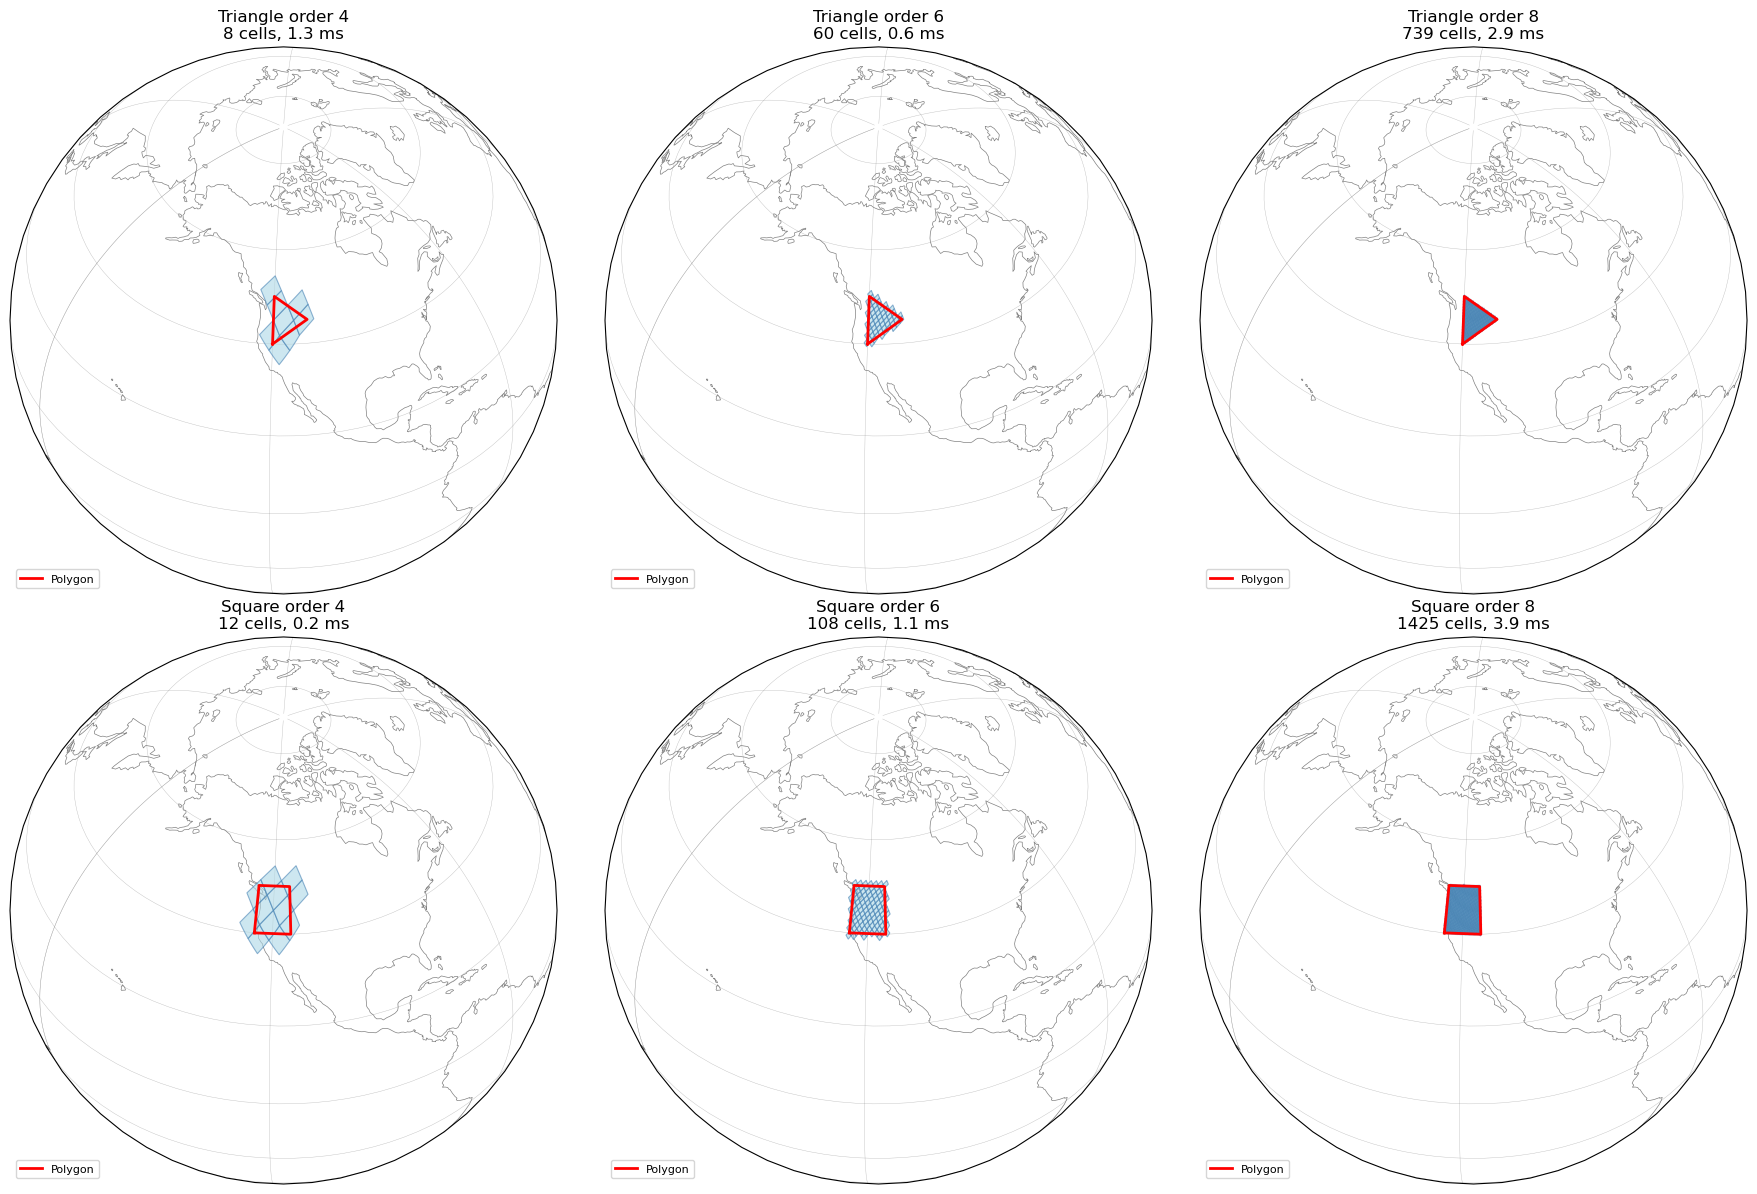

In [3]:
# Triangle
lats_t = np.array([40.0, 50.0, 45.0])
lons_t = np.array([-120.0, -120.0, -110.0])

# Square
lats_s = np.array([40.0, 40.0, 50.0, 50.0])
lons_s = np.array([-125.0, -115.0, -115.0, -125.0])

fig = plt.figure(figsize=(18, 12))
proj = ccrs.Orthographic(central_longitude=-117, central_latitude=45)

for row, (name, la, lo) in enumerate([('Triangle', lats_t, lons_t), ('Square', lats_s, lons_s)]):
    for col, order in enumerate([4, 6, 8]):
        ax = fig.add_subplot(2, 3, row*3 + col + 1, projection=proj)
        ax.set_global()
        plot_coverage(la, lo, order, ax, title=f'{name} order {order}')

plt.tight_layout()
plt.show()

## Circle (100 vertices, southern hemisphere) — South Polar

A challenging case: a circular polygon near the south pole (lat -75, radius 5 deg).
Longitudes converge at the pole, so boundary cell geometries are tricky to render.
Pole-touching cells use stereographic projection to avoid the "bowtie" artefact.

/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


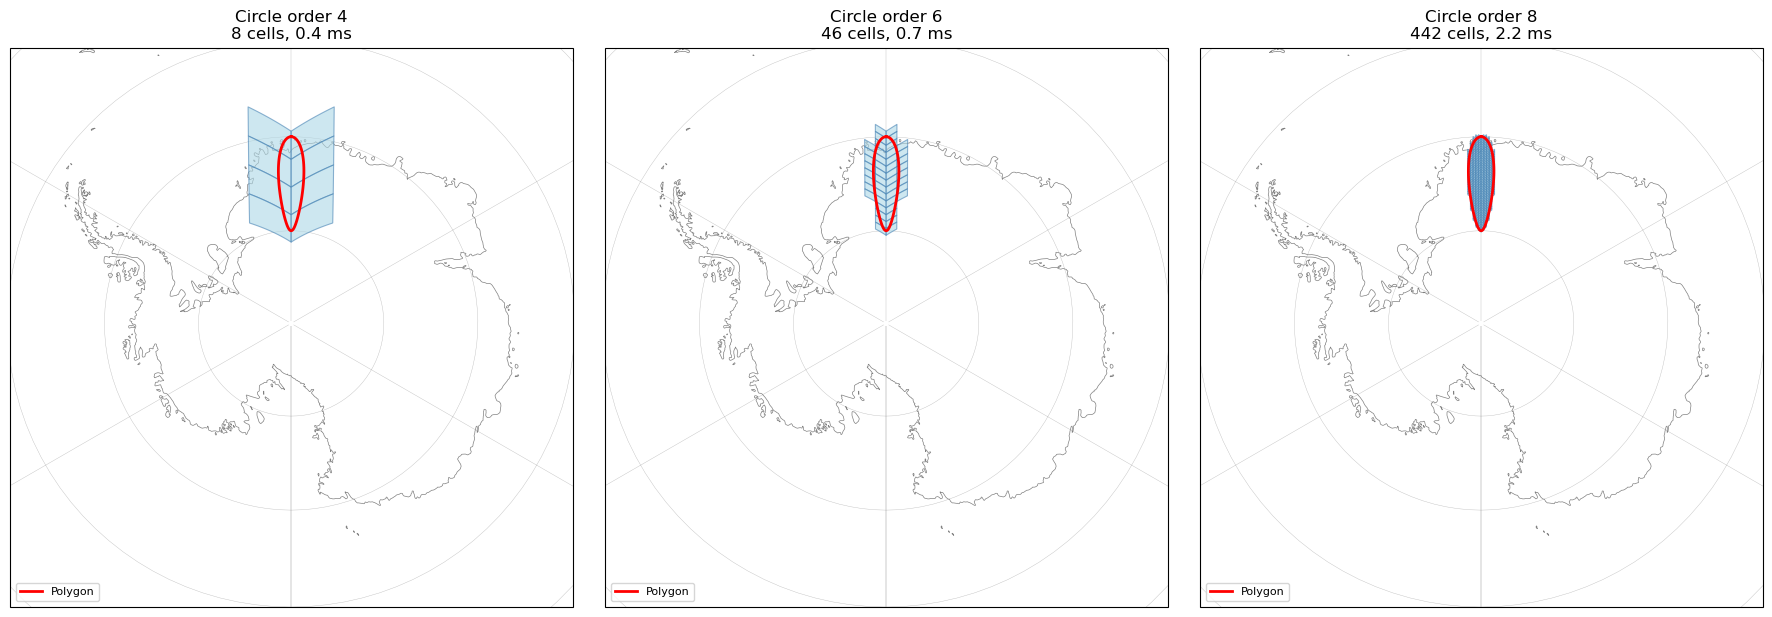

In [4]:
n = 100
angles = np.linspace(0, 2*np.pi, n, endpoint=False)
lats_c = -75.0 + 5.0 * np.cos(angles)
lons_c = 0.0 + 5.0 * np.sin(angles)

fig = plt.figure(figsize=(18, 6))
proj = ccrs.SouthPolarStereo()

for i, order in enumerate([4, 6, 8]):
    ax = fig.add_subplot(1, 3, i+1, projection=proj)
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    plot_coverage(lats_c, lons_c, order, ax, title=f'Circle order {order}')

plt.tight_layout()
plt.show()

## Antarctic Drainage Basins — South Polar Stereographic

Three representative basins from the Antarctic grounded drainage system dataset:
- **Basin 24** (smallest, ~21k vertices) — compact region, tests small-polygon handling
- **Basin 1** (largest, ~81k vertices) — wide basin, tests large interior flood fill
- **Basin 2** (pole + antimeridian crossing, ~43k vertices) — the hardest case, stresses both longitude wrapping and polar geometry

Polygons are simplified to ~500 vertices for faster plotting (coverage is computed on the simplified version).

/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


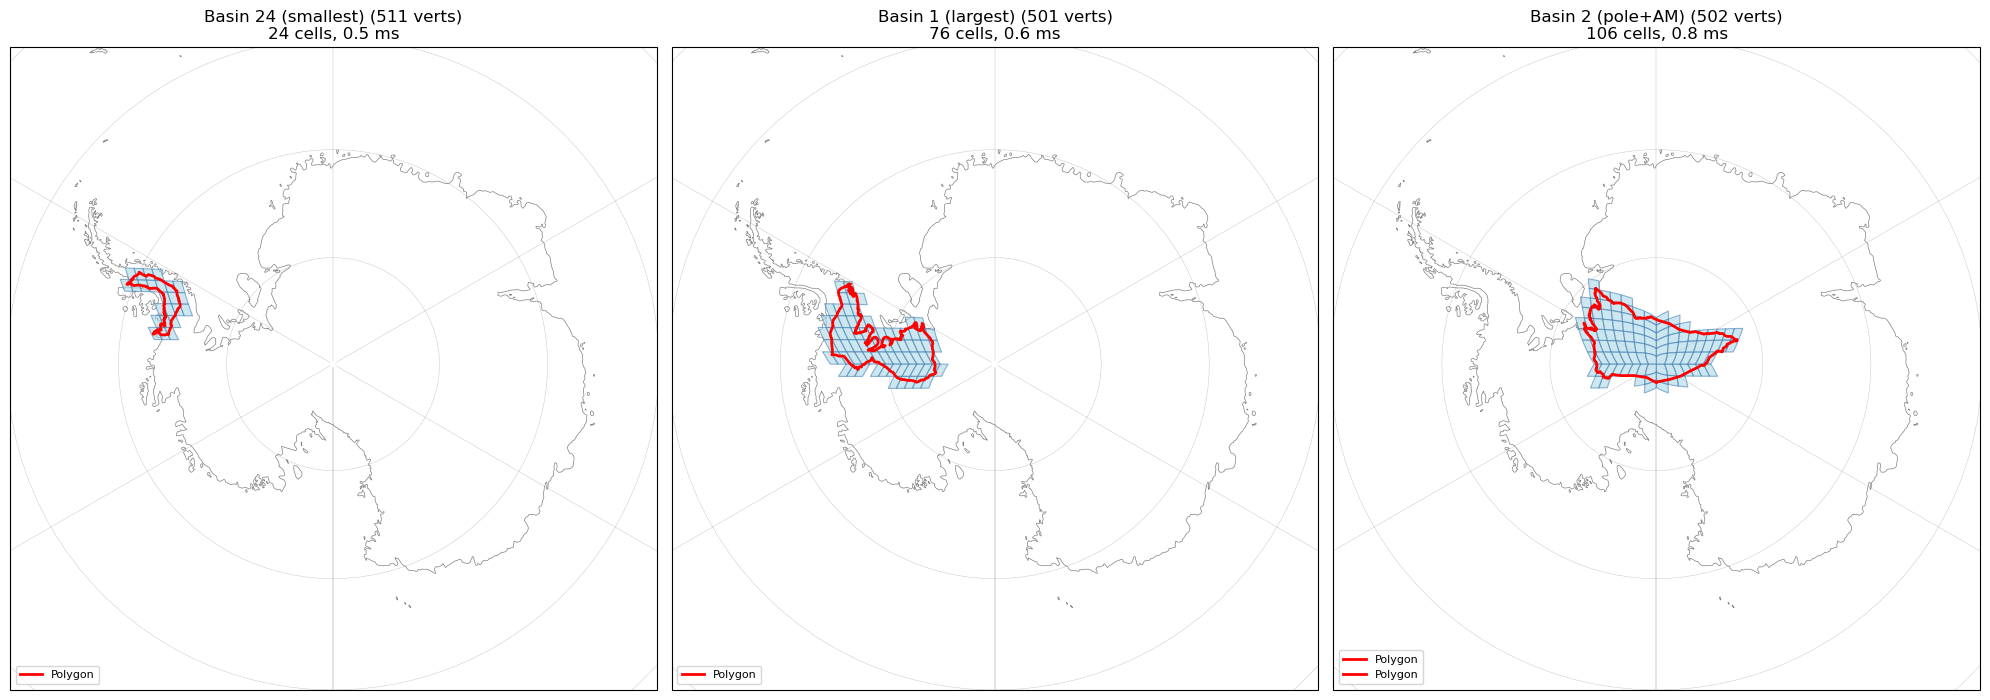

In [5]:
data_file = Path('../mortie/tests/Ant_Grounded_DrainageSystem_Polygons.txt')
assert data_file.exists(), 'Antarctic polygon data not found'
data = np.loadtxt(data_file)

fig = plt.figure(figsize=(20, 7))
proj = ccrs.SouthPolarStereo()

for idx, (bid, name) in enumerate([
    (24, 'Basin 24 (smallest)'),
    (1, 'Basin 1 (largest)'),
    (2, 'Basin 2 (pole+AM)')
]):
    mask = data[:, 2] == bid
    lats = data[mask, 0]
    lons = data[mask, 1]

    # Simplify for plotting
    step = max(1, len(lats) // 500)
    la_s, lo_s = lats[::step], lons[::step]

    ax = fig.add_subplot(1, 3, idx+1, projection=proj)
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    plot_coverage(la_s, lo_s, order=6, ax=ax, title=f'{name} ({len(la_s)} verts)')

plt.tight_layout()
plt.show()

## Full Antarctica — All 27 Drainage Basins (Multipart, Order 6)

Demonstrates **multipart polygon** support: pass `lats` and `lons` as lists of arrays
(one per basin). The coverage of all parts is unioned into a single sorted array.

This is a production-scale use case: 27 basins, ~1M total vertices.

27 basins, 1,239,001 total vertices
Coverage: 1334 cells in 322.6 ms


/home/espg/.local/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


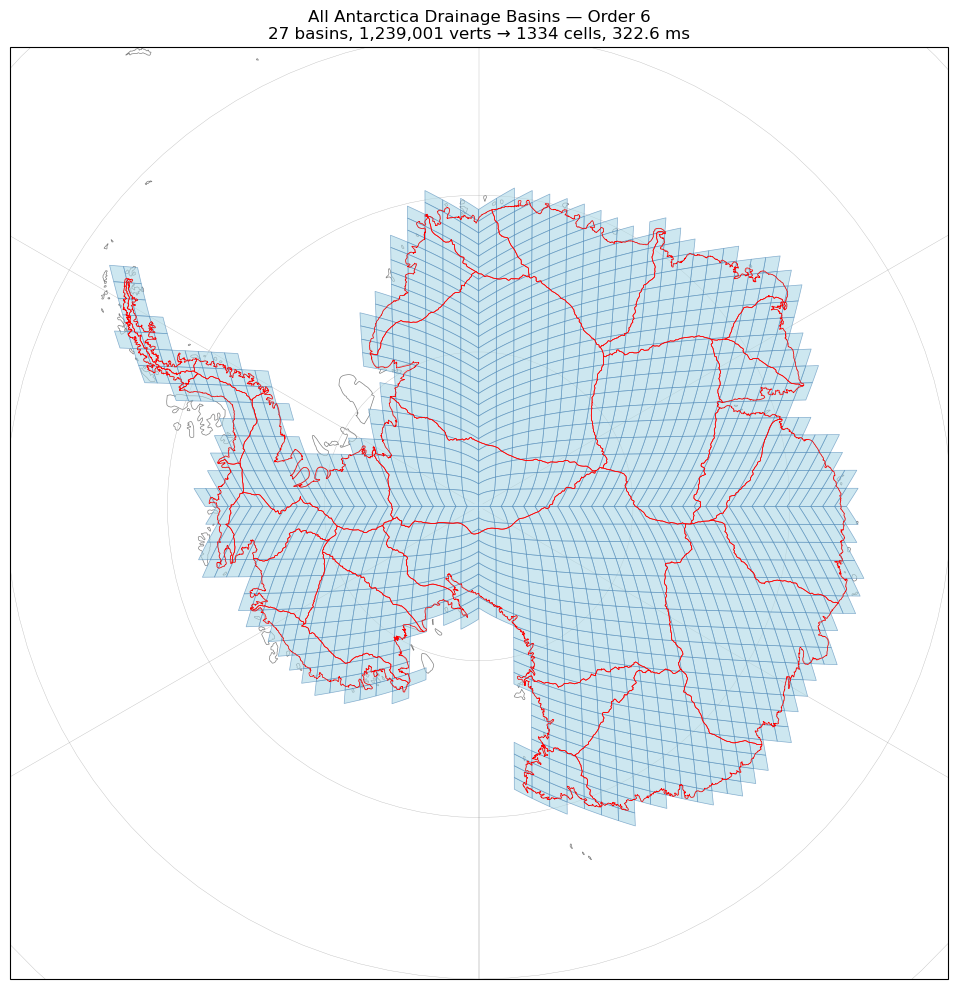

In [6]:
# Build multipart polygon: one part per basin (unsimplified)
basin_ids = np.unique(data[:, 2]).astype(int)
lats_parts = []
lons_parts = []
total_verts = 0
for bid in basin_ids:
    mask = data[:, 2] == bid
    lats_parts.append(data[mask, 0])
    lons_parts.append(data[mask, 1])
    total_verts += mask.sum()

print(f'{len(basin_ids)} basins, {total_verts:,} total vertices')

# Run multipart coverage
t0 = time.perf_counter()
cells = mortie.morton_coverage(lats_parts, lons_parts, order=6)
dt = (time.perf_counter() - t0) * 1000
print(f'Coverage: {len(cells)} cells in {dt:.1f} ms')

# Plot
fig = plt.figure(figsize=(10, 10))
proj = ccrs.SouthPolarStereo()
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

# Cell boundaries
geoms = morton_cell_geometries(cells)
ax.add_geometries(
    geoms, crs=ccrs.PlateCarree(),
    facecolor='lightblue', edgecolor='steelblue',
    linewidth=0.5, alpha=0.6, zorder=3,
)

# Plot each basin polygon boundary
for la, lo in zip(lats_parts, lons_parts):
    plot_polygon_boundary(lo, la, ax, color='r', linewidth=0.5, zorder=4)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)
ax.set_title(f'All Antarctica Drainage Basins — Order 6\n'
             f'{len(basin_ids)} basins, {total_verts:,} verts → {len(cells)} cells, {dt:.1f} ms')
plt.tight_layout()
plt.show()

## Performance Summary

Timing breakdown across polygon types and orders. Key factors:
- **Phase A** (boundary interpolation) scales with vertex count and edge lengths
- **Phase B** (buffer + classification) is typically fast
- **Phase C** (flood fill) scales with the number of interior cells

In [7]:
results = []

polys = [
    ('Triangle', np.array([40.0,50.0,45.0]), np.array([-120.0,-120.0,-110.0])),
    ('Square', np.array([40.0,40.0,50.0,50.0]), np.array([-125.0,-115.0,-115.0,-125.0])),
]
n = 100
angles = np.linspace(0, 2*np.pi, n, endpoint=False)
polys.append(('Circle100', -75.0 + 5.0*np.cos(angles), 0.0 + 5.0*np.sin(angles)))

for name, la, lo in polys:
    for order in [4, 6, 8]:
        times = []
        for _ in range(5):
            t0 = time.perf_counter()
            cells = mortie.morton_coverage(la, lo, order=order)
            times.append((time.perf_counter()-t0)*1000)
        results.append((name, len(la), order, np.median(times), len(cells)))

for bid in [24, 1, 2]:
    mask = data[:, 2] == bid
    lats = data[mask, 0]; lons = data[mask, 1]
    for order in [4, 6]:
        t0 = time.perf_counter()
        cells = mortie.morton_coverage(lats, lons, order=order)
        dt = (time.perf_counter()-t0)*1000
        results.append((f'Basin {bid}', len(lats), order, dt, len(cells)))

print(f'{"Polygon":<15} {"Verts":>8} {"Order":>6} {"Time (ms)":>10} {"Cells":>8}')
print('-' * 52)
for name, verts, order, ms, ncells in results:
    print(f'{name:<15} {verts:>8} {order:>6} {ms:>10.1f} {ncells:>8}')

Polygon            Verts  Order  Time (ms)    Cells
----------------------------------------------------
Triangle               3      4        0.2        8
Triangle               3      6        0.7       60
Triangle               3      8        3.0      739
Square                 4      4        0.2       12
Square                 4      6        0.6      108
Square                 4      8        2.7     1425
Circle100            100      4        0.1        8
Circle100            100      6        0.2       46
Circle100            100      8        0.9      442
Basin 24           21965      4        2.4        5
Basin 24           21965      6        1.8       24
Basin 1            81595      4       12.2       11
Basin 1            81595      6       14.5       76
Basin 2            43096      4        3.3       12
Basin 2            43096      6        5.7      106
